In [ ]:
# Celula 1: prepara o ambiente de trabalho para toda a analise.
# - pandas/numpy: manipulacao de dados
# - matplotlib: graficos
# - scikit-learn: validacao cruzada e metricas
# - xgboost: modelo de classificacao
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import TimeSeriesSplit
# from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    r2_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    brier_score_loss,
    log_loss,
    ConfusionMatrixDisplay,
)

# Instala automaticamente o xgboost apenas se ele nao estiver disponivel.
try:
    from xgboost import XGBClassifier
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
    from xgboost import XGBClassifier

# Instala automaticamente o optuna apenas se ele nao estiver disponivel.
try:
    import optuna
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna", "-q"])
    import optuna

# Instala automaticamente o optuna-dashboard apenas se ele nao estiver disponivel.
try:
    import optuna_dashboard
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna-dashboard", "-q"])
    import optuna_dashboard

# Mostra todas as colunas ao inspecionar DataFrames.
pd.set_option("display.max_columns", None)
print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


In [225]:
# Celula 2: leitura da base e preparo das variaveis de entrada.
csv_path = Path(r"C:\Users\otavi\OneDrive\Desktop\last-mile-tcc\backend\tabela_final\part-00000-13fcc452-2493-4299-ab17-d369f64d2ad3-c000.csv")
df = pd.read_csv(csv_path)

target_col = "delivered_on_time"
if target_col not in df.columns:
    raise ValueError(f"A coluna alvo '{target_col}' nao foi encontrada no CSV.")

# =====================================================================
# 1. ENGENHARIA DO SLA (Prazo da Transportadora)
# =====================================================================
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'], utc=True)
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'], utc=True)

# quantos dias a transportadora tem para entregar?
df['prazo_transportadora_dias'] = (df['order_estimated_delivery_date'] - df['order_delivered_carrier_date']).dt.days

# =====================================================================
# 2. ORDENAÇÃO CRONOLÓGICA (Obrigatório para TimeSeriesSplit)
# =====================================================================
df = df.sort_values('order_delivered_carrier_date').reset_index(drop=True)

# Divide em treino/teste com split temporal (Passado treina, Futuro testa).
# Treino: ate Junho de 2018 | Teste: Julho de 2018 em diante.
date_col = df['order_delivered_carrier_date'].copy()
split_date = pd.to_datetime("2018-07-01", utc=True)

leakage_candidates = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "shipping_delay_hours",
    "delivery_time_days",
    "review_score",
]
leakage_cols = [c for c in leakage_candidates if c in df.columns]

# Separa previsores e alvo.
feature_cols = [c for c in df.columns if c != target_col and c not in leakage_cols]
X = df[feature_cols].copy()
# Inverte o alvo: atraso = 1, no prazo = 0.
y = (~df[target_col].astype(bool)).astype(int).copy()

colunas_remover = [
    "order_purchase_timestamp",
    "order_approved_at",
    "interval_code_delivered_carrier",
    "interval_code_delivered_customer",
    "order_estimated_delivery_date", # Já usamos, podemos apagar
    "shipping_limit_date",
    "had_holiday_14_days_ago",
    "days_since_last_holiday",
    "days_until_next_holiday",
    "delivered_on_time",
    "customer_city",
    "seller_city",
    "category_name", 
    "review_score"
]

# colunas_remover = [
#     # Vazamento de dados / multicolinearidade
#     "order_purchase_timestamp",
#     "order_approved_at",
#     "order_delivered_carrier_date",
#     "interval_code_delivered_carrier",
#     "order_delivered_customer_date",
#     "interval_code_delivered_customer",
#     "order_estimated_delivery_date",
#     "shipping_limit_date",
#     "is_holiday_in_7_days",
#     "is_holiday_in_14_days",
#     "had_holiday_7_days_ago",
#     "had_holiday_14_days_ago",
#     "delivered_on_time",
#     "customer_city",
#     "seller_city",
#     "category_name",
#     "review_score",
#     "delivery_time_days"
# ]

X = X.drop(columns=colunas_remover, errors='ignore')

train_mask = date_col < split_date
test_mask = date_col >= split_date

X_train = X[train_mask].copy()
y_train = y[train_mask].copy()
X_test = X[test_mask].copy()
y_test = y[test_mask].copy()

# # =====================================================================
# # ENGENHARIA DE FEATURES: TARGET ENCODING SUAVIZADO
# # =====================================================================
# media_global_atraso = y_train.mean()
# m = 10 

# counts_customer = X_train['customer_city'].value_counts()
# means_customer = y_train.groupby(X_train['customer_city']).mean()
# smooth_customer = (counts_customer * means_customer + m * media_global_atraso) / (counts_customer + m)

# counts_seller = X_train['seller_city'].value_counts()
# means_seller = y_train.groupby(X_train['seller_city']).mean()
# smooth_seller = (counts_seller * means_seller + m * media_global_atraso) / (counts_seller + m)

# X_train['customer_city_encoded'] = X_train['customer_city'].map(smooth_customer)
# X_train['seller_city_encoded'] = X_train['seller_city'].map(smooth_seller)
# X_test['customer_city_encoded'] = X_test['customer_city'].map(smooth_customer).fillna(media_global_atraso)
# X_test['seller_city_encoded'] = X_test['seller_city'].map(smooth_seller).fillna(media_global_atraso)

# X_train = X_train.drop(columns=['customer_city', 'seller_city'])
# X_test = X_test.drop(columns=['customer_city', 'seller_city'])

# from sklearn.preprocessing import StandardScaler
# scale_obj = StandardScaler()

# X_train = pd.DataFrame(scale_obj.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
# X_test = pd.DataFrame(scale_obj.transform(X_test), columns=X_test.columns, index=X_test.index)

# X_train = X_train.drop(columns=['customer_city_encoded', 'seller_city_encoded'])
# X_test = X_test.drop(columns=['customer_city_encoded', 'seller_city_encoded'])

pos_count = int((y_train == 1).sum())
total_linhas = len(X)
qtd_treino = len(X_train)
qtd_teste = len(X_test)

print(f"Total de registros: Linhas: {X.shape[0]:,} | Colunas: {X.shape[1]}\n")
print(f"Treino (ate Jun/2018): {qtd_treino:,} ({qtd_treino/total_linhas:.2%})")
print(f" - Atrasos no Treino: {pos_count} ({(y_train == 1).mean():.2%} do treino)\n")
print(f"Teste (Jul/2018 em diante): {qtd_teste:,} ({qtd_teste/total_linhas:.2%})")
print(f" - Atrasos no Teste: {(y_test == 1).sum()} ({(y_test == 1).mean():.2%} do teste)\n")

X_test.head()

Total de registros: Linhas: 33,820 | Colunas: 14

Treino (ate Jun/2018): 28,706 (84.88%)
 - Atrasos no Treino: 1425 (4.96% do treino)

Teste (Jul/2018 em diante): 5,114 (15.12%)
 - Atrasos no Teste: 613 (11.99% do teste)



,holiday_at_purchase,is_holiday_in_7_days,is_holiday_in_14_days,had_holiday_7_days_ago,purchase_hour,purchase_day_of_week,is_weekend,price,freight_value,product_weight_g,volume_cm3,distance_km,same_city,prazo_transportadora_dias
28706,0,0,1,0,15,5,1,58.99,13.07,200,3960.0,65.936,0,16
28707,0,0,1,0,20,5,1,24.99,13.76,2350,10648.0,411.255,0,16
28708,0,0,1,0,10,6,1,119.90,13.50,459,3276.0,284.778,0,20
28709,0,0,1,0,8,6,1,49.00,13.00,250,640.0,221.179,0,17
28710,0,0,1,0,14,5,1,106.00,17.95,3305,35100.0,112.930,0,10


In [226]:
# Celula 3: define funcoes e configuracoes da busca de hiperparametros.
# A avaliacao desta analise trata "atraso" como classe positiva (1).
def metricas_atraso(y_true, y_pred_atraso, y_proba_atraso):
    return {
        "accuracy_atraso": accuracy_score(y_true, y_pred_atraso),
        "precision_atraso": precision_score(y_true, y_pred_atraso, zero_division=0),
        "recall_atraso": recall_score(y_true, y_pred_atraso, zero_division=0),
        "f1_atraso": f1_score(y_true, y_pred_atraso, zero_division=0),
        "f2_atraso": fbeta_score(y_true, y_pred_atraso, beta=2, zero_division=0),
        "roc_auc_atraso": roc_auc_score(y_true, y_proba_atraso),
        "pr_auc_atraso": average_precision_score(y_true, y_proba_atraso),
        "r2_atraso": r2_score(y_true, y_proba_atraso),
        "balanced_accuracy_atraso": balanced_accuracy_score(y_true, y_pred_atraso),
        "mcc_atraso": matthews_corrcoef(y_true, y_pred_atraso),
        "brier_score_atraso": brier_score_loss(y_true, y_proba_atraso),
        "log_loss_atraso": log_loss(y_true, y_proba_atraso),
    }


def metricas_gerais(y_true, y_pred, y_proba):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "PR-AUC": average_precision_score(y_true, y_proba),
        "R2": r2_score(y_true, y_proba),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Brier Score": brier_score_loss(y_true, y_proba),
        "Log Loss": log_loss(y_true, y_proba),
    }

# Configuracao do Optuna para busca de hiperparametros.
n_trials = 35
study_seed = 42
cv_tune = TimeSeriesSplit(n_splits=3)
threshold_grid_tune = np.arange(0.02, 0.30, 0.01)

# Vetor binario: 1 = atraso, 0 = nao atraso.
y_train_atraso = y_train.values

print("Preparacao da busca de hiperparametros concluida.")

Preparacao da busca de hiperparametros concluida.


In [227]:
# Celula 4: busca de hiperparametros com Optuna + validacao cruzada.
# Criterio de selecao: maior PR-AUC. Limiar escolhido pelo F2 com desempate por recall e precision.
optuna_db_path = Path("optuna_xgb_temporal.db").resolve()
study_storage = f"sqlite:///{optuna_db_path.as_posix()}"
study_name = "xgb_temporal_split"

def objective(trial):
    params = {
        # Menos árvores para evitar a memorização a longo prazo
        "n_estimators": trial.suggest_int("n_estimators", 100, 300, step=50),
        
        # Árvores MUITO rasas (o padrão do XGBoost é 6, vamos limitar a 4)
        "max_depth": trial.suggest_int("max_depth", 2, 4),
        
        # Taxa de aprendizado mais conservadora
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.1),
        
        # Efeito Random Forest (usa apenas uma % das colunas e linhas por árvore)
        "subsample": trial.suggest_float("subsample", 0.5, 0.8),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.8),
        
        # REGULARIZAÇÃO PESADA: Exige que o nó tenha "muito peso" para ser criado
        "min_child_weight": trial.suggest_int("min_child_weight", 10, 50),
        
        # Poda agressiva: Só divide a árvore se a redução de erro for muito boa
        "gamma": trial.suggest_float("gamma", 1.0, 5.0),
        
        # Penalidades matemáticas para pesos muito grandes
        "reg_alpha": trial.suggest_float("reg_alpha", 0.5, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 2.0, 10.0)
    }
    oof_proba_atraso = np.zeros(len(y_train), dtype=float)

    for fold, (tr_idx, va_idx) in enumerate(cv_tune.split(X_train, y_train), start=1):
        # 1. Extraímos também o y correspondente à validação
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        # 2. Ajustamos os parâmetros do modelo (padrão para XGBoost >= 1.6)
        mdl = XGBClassifier(
            objective="binary:logistic",
            eval_metric="aucpr", # Alterado para focar na Curva Precision-Recall
            early_stopping_rounds=50, # Para o treinamento se o aucpr não melhorar por 50 rodadas
            random_state=1000 + trial.number * 10 + fold,
            n_jobs=-1,
            **params,
        )
        
        # 3. Passamos os dados de validação através do eval_set
        mdl.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            verbose=False # Desativado para não poluir o terminal durante a busca de hiperparâmetros
        )

        # Probabilidade de atraso = classe positiva (1).
        proba_atraso_va = mdl.predict_proba(X_va)[:, 1]
        oof_proba_atraso[va_idx] = proba_atraso_va

    pr_auc_i = average_precision_score(y_train_atraso, oof_proba_atraso)

    # Para cada conjunto de parametros, busca o melhor limiar de decisao.
    best_thr_i = 0.50
    best_f2_i = -1.0
    best_recall_i = -1.0
    best_precision_i = -1.0

    for thr in threshold_grid_tune:
        pred_atraso = (oof_proba_atraso >= thr).astype(int)
        precision_i = precision_score(y_train_atraso, pred_atraso, zero_division=0)
        recall_i = recall_score(y_train_atraso, pred_atraso, zero_division=0)
        f2_i = fbeta_score(y_train_atraso, pred_atraso, beta=1, zero_division=0)

        if (f2_i > best_f2_i) or (np.isclose(f2_i, best_f2_i) and recall_i > best_recall_i) or (
            np.isclose(f2_i, best_f2_i) and np.isclose(recall_i, best_recall_i) and precision_i > best_precision_i
        ):
            best_f2_i = float(f2_i)
            best_recall_i = float(recall_i)
            best_precision_i = float(precision_i)
            best_thr_i = float(thr)

    trial.set_user_attr("best_threshold", best_thr_i)
    trial.set_user_attr("cv_pr_auc_atraso", pr_auc_i)
    trial.set_user_attr("cv_f2_atraso", best_f2_i)
    trial.set_user_attr("cv_recall_atraso", best_recall_i)
    trial.set_user_attr("cv_precision_atraso", best_precision_i)

    return pr_auc_i

sampler = optuna.samplers.TPESampler(seed=study_seed)
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name=study_name,
    load_if_exists=True,
)
study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

best_trial = study.best_trial
best_params_v2 = best_trial.params
best_threshold_v2 = float(best_trial.user_attrs["best_threshold"])

tuning_rows = []
for t in study.trials:
    if t.value is None:
        continue
    tuning_rows.append({
        "candidate": t.number + 1,
        "cv_pr_auc_atraso": t.user_attrs.get("cv_pr_auc_atraso", np.nan),
        "cv_f2_atraso": t.user_attrs.get("cv_f2_atraso", np.nan),
        "cv_recall_atraso": t.user_attrs.get("cv_recall_atraso", np.nan),
        "cv_precision_atraso": t.user_attrs.get("cv_precision_atraso", np.nan),
        "best_threshold": t.user_attrs.get("best_threshold", np.nan),
        "params": t.params,
    })

df_tuning = pd.DataFrame(tuning_rows).sort_values(
    ["cv_pr_auc_atraso", "cv_f2_atraso", "cv_recall_atraso", "cv_precision_atraso"], ascending=False
).reset_index(drop=True)

print(f"Trials avaliados: {len(df_tuning)}")
print("Top 8 configuracoes pela validacao cruzada (PR-AUC -> F2 -> Recall):")
display(df_tuning.head(8))
print("\nMelhores hiperparametros encontrados:")
for key, value in best_params_v2.items():
    print(f" - {key}: {value}")
print(f"Melhor limiar (Optuna): {best_threshold_v2:.2f}")
print(f"Study name: {study_name}")
print(f"Comando dashboard: optuna-dashboard {study_storage} --port 8080")

[I 2026-06-23 00:21:03,941] A new study created in memory with name: xgb_temporal_split


[I 2026-06-23 00:21:05,520] Trial 0 finished with value: 0.26141684307056606 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.07587945476302646, 'subsample': 0.679597545259111, 'colsample_bytree': 0.5468055921327309, 'min_child_weight': 16, 'gamma': 1.2323344486727978, 'reg_alpha': 4.3977926559872085, 'reg_lambda': 6.80892009394567}. Best is trial 0 with value: 0.26141684307056606.
[I 2026-06-23 00:21:06,917] Trial 1 finished with value: 0.26244191442380094 and parameters: {'n_estimators': 250, 'max_depth': 2, 'learning_rate': 0.0972918866945795, 'subsample': 0.7497327922401266, 'colsample_bytree': 0.5637017332034828, 'min_child_weight': 17, 'gamma': 1.7336180394137353, 'reg_alpha': 1.8690900933179198, 'reg_lambda': 6.198051453057903}. Best is trial 1 with value: 0.26244191442380094.
[I 2026-06-23 00:21:08,720] Trial 2 finished with value: 0.23855246445463296 and parameters: {'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.06506676052501416, 'subsample':

Trials avaliados: 35
Top 8 configuracoes pela validacao cruzada (PR-AUC -> F2 -> Recall):


,candidate,cv_pr_auc_atraso,cv_f2_atraso,cv_recall_atraso,cv_precision_atraso,best_threshold,params
0,22,0.278708,0.304793,0.261053,0.366142,0.17,"{'n_estimators': 100, 'max_depth': 3, 'learnin..."
1,20,0.278240,0.307906,0.233684,0.451220,0.23,"{'n_estimators': 150, 'max_depth': 3, 'learnin..."
2,14,0.275679,0.301987,0.240000,0.407143,0.20,"{'n_estimators': 100, 'max_depth': 4, 'learnin..."
3,9,0.275319,0.303181,0.257544,0.368474,0.18,"{'n_estimators': 100, 'max_depth': 4, 'learnin..."
4,32,0.275219,0.307375,0.261754,0.372255,0.17,"{'n_estimators': 100, 'max_depth': 4, 'learnin..."
5,25,0.275182,0.303366,0.249825,0.386117,0.19,"{'n_estimators': 150, 'max_depth': 3, 'learnin..."
6,29,0.274970,0.303646,0.230877,0.443396,0.23,"{'n_estimators': 150, 'max_depth': 3, 'learnin..."
7,15,0.274883,0.303890,0.232982,0.436842,0.22,"{'n_estimators': 100, 'max_depth': 4, 'learnin..."



Melhores hiperparametros encontrados:
 - n_estimators: 100
 - max_depth: 3
 - learning_rate: 0.0712932431744912
 - subsample: 0.7072505171773176
 - colsample_bytree: 0.7073305904451536
 - min_child_weight: 10
 - gamma: 2.694843069574856
 - reg_alpha: 0.9755196847688334
 - reg_lambda: 9.029016052664264
Melhor limiar (Optuna): 0.17
Study name: xgb_temporal_split
Comando dashboard: optuna-dashboard sqlite:///C:/Users/otavi/OneDrive/Desktop/last-mile-tcc/backend/modelo/split-temporal/optuna_xgb_temporal.db --port 8080


[0]	validation_0-aucpr:0.10735
[10]	validation_0-aucpr:0.52007
[20]	validation_0-aucpr:0.73337
[30]	validation_0-aucpr:0.75473
[40]	validation_0-aucpr:0.75563
[50]	validation_0-aucpr:0.75533
[60]	validation_0-aucpr:0.75420
[70]	validation_0-aucpr:0.75341
[80]	validation_0-aucpr:0.75280
[88]	validation_0-aucpr:0.75087
Metricas no teste (foco em atraso):


,Teste
accuracy_atraso,0.7759
precision_atraso,0.3358
recall_atraso,0.8891
f1_atraso,0.4875
f2_atraso,0.6687
roc_auc_atraso,0.9146
pr_auc_atraso,0.7558
r2_atraso,0.3991
balanced_accuracy_atraso,0.8248
mcc_atraso,0.4533



Como interpretar as metricas:
- precision_atraso: entre os pedidos previstos como atraso, quantos realmente atrasaram.
- recall_atraso: entre os pedidos que realmente atrasaram, quantos o modelo conseguiu detectar.
- f1_atraso: media harmonica entre precision e recall (equilibrio entre os dois).
- f2_atraso: semelhante ao F1, mas dando mais peso ao recall (bom para nao perder atrasos).
- roc_auc_atraso: capacidade de separar atraso vs nao atraso em todos os limiares (quanto maior, melhor).
- pr_auc_atraso: qualidade do modelo no trade-off precision x recall para classe rara (atraso).


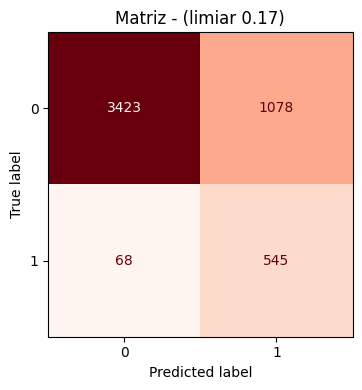

Resumo (teste):
- Limiar adotado: 0.17
- Precision atraso: 0.3358
- Recall atraso: 0.8891
- F2 atraso: 0.6687
- ROC-AUC atraso: 0.9146
- PR-AUC atraso: 0.7558
- R2 atraso: 0.3991


In [228]:
# Celula 5: treino final do modelo com os melhores hiperparametros + avaliacao no teste.
model_v2 = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",       # Correção: nome do parâmetro é eval_metric
    early_stopping_rounds=50,
    random_state=4242,
    n_jobs=-1,
    # scale_pos_weight=scale_pos_weight,
    **best_params_v2,
)

# Passamos o conjunto de teste para o eval_set
model_v2.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)], 
    verbose=10  # Mostra o progresso do aucpr a cada 10 iterações (ajuda a ver onde o modelo estabiliza)
)

# Probabilidade de atraso (classe 1).
y_proba_v2_train = model_v2.predict_proba(X_train)[:, 1]
y_proba_v2_test = model_v2.predict_proba(X_test)[:, 1]

y_pred_v2_train = (y_proba_v2_train >= best_threshold_v2).astype(int)
y_pred_v2_test = (y_proba_v2_test >= best_threshold_v2).astype(int)

res_v2_train = metricas_atraso(y_train, y_pred_v2_train, y_proba_v2_train)
res_v2_test = metricas_atraso(y_test, y_pred_v2_test, y_proba_v2_test)
metricas_treino_v2 = metricas_gerais(y_train, y_pred_v2_train, y_proba_v2_train)
metricas_teste_v2 = metricas_gerais(y_test, y_pred_v2_test, y_proba_v2_test)

print("Metricas no teste (foco em atraso):")
display(pd.DataFrame(pd.Series(res_v2_test, name="Teste")).round(4))

# Explicacao breve das metricas para leitura dos resultados.
print("\nComo interpretar as metricas:")
print("- precision_atraso: entre os pedidos previstos como atraso, quantos realmente atrasaram.")
print("- recall_atraso: entre os pedidos que realmente atrasaram, quantos o modelo conseguiu detectar.")
print("- f1_atraso: media harmonica entre precision e recall (equilibrio entre os dois).")
print("- f2_atraso: semelhante ao F1, mas dando mais peso ao recall (bom para nao perder atrasos).")
print("- roc_auc_atraso: capacidade de separar atraso vs nao atraso em todos os limiares (quanto maior, melhor).")
print("- pr_auc_atraso: qualidade do modelo no trade-off precision x recall para classe rara (atraso).")

# Exibe matriz de confusao para visualizar erros da V2 no teste.
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_v2_test, cmap="Reds", ax=ax, colorbar=False
)
ax.set_title(f"Matriz - (limiar {best_threshold_v2:.2f})")
plt.tight_layout()
plt.show()

print("Resumo (teste):")
print(f"- Limiar adotado: {best_threshold_v2:.2f}")
print(f"- Precision atraso: {res_v2_test['precision_atraso']:.4f}")
print(f"- Recall atraso: {res_v2_test['recall_atraso']:.4f}")
print(f"- F2 atraso: {res_v2_test['f2_atraso']:.4f}")
print(f"- ROC-AUC atraso: {res_v2_test['roc_auc_atraso']:.4f}")
print(f"- PR-AUC atraso: {res_v2_test['pr_auc_atraso']:.4f}")
print(f"- R2 atraso: {res_v2_test['r2_atraso']:.4f}")

In [229]:
# Celula 6: tabelas de metricas de atraso (classe 1).
print("=" * 120)
print("METRICAS DE ATRASO (CLASSE 1)")
print("=" * 120)

print("\n(Accuracy, Precision, Recall, F1, F2, ROC-AUC, PR-AUC, Balanced Accuracy, MCC, Brier Score, Log Loss)")

print("\n" + "-" * 120)
print("TREINO (ATRASO)")
print("-" * 120)
df_v2_train_atraso = pd.DataFrame(pd.Series(res_v2_train, name="Treino"))
display(df_v2_train_atraso.round(4))

print("\n" + "-" * 120)
print("TESTE (ATRASO)")
print("-" * 120)
df_v2_test_atraso = pd.DataFrame(pd.Series(res_v2_test, name="Teste"))
display(df_v2_test_atraso.round(4))

# ============================================================================
# RESUMO
# ============================================================================
print("RESUMO\n")
print("─" * 120 + "\n")
print(f"  Limiar utilizado: {best_threshold_v2:.2f}")
print(
    f"  Treino - Accuracy: {metricas_treino_v2['Accuracy']:.4f}, ROC-AUC: {metricas_treino_v2['ROC-AUC']:.4f}, R2: {metricas_treino_v2['R2']:.4f}, "
    f"Precision (Atraso): {res_v2_train['precision_atraso']:.4f}, Recall (Atraso): {res_v2_train['recall_atraso']:.4f}"
)
print(
    f"  Teste  - Accuracy: {metricas_teste_v2['Accuracy']:.4f}, ROC-AUC: {metricas_teste_v2['ROC-AUC']:.4f}, R2: {metricas_teste_v2['R2']:.4f}, "
    f"Precision (Atraso): {res_v2_test['precision_atraso']:.4f}, Recall (Atraso): {res_v2_test['recall_atraso']:.4f}"
)



METRICAS DE ATRASO (CLASSE 1)

(Accuracy, Precision, Recall, F1, F2, ROC-AUC, PR-AUC, Balanced Accuracy, MCC, Brier Score, Log Loss)

------------------------------------------------------------------------------------------------------------------------
TREINO (ATRASO)
------------------------------------------------------------------------------------------------------------------------


,Treino
accuracy_atraso,0.9547
precision_atraso,0.5960
recall_atraso,0.2702
f1_atraso,0.3718
f2_atraso,0.3033
roc_auc_atraso,0.8059
pr_auc_atraso,0.3922
r2_atraso,0.1944
balanced_accuracy_atraso,0.6303
mcc_atraso,0.3817



------------------------------------------------------------------------------------------------------------------------
TESTE (ATRASO)
------------------------------------------------------------------------------------------------------------------------


,Teste
accuracy_atraso,0.7759
precision_atraso,0.3358
recall_atraso,0.8891
f1_atraso,0.4875
f2_atraso,0.6687
roc_auc_atraso,0.9146
pr_auc_atraso,0.7558
r2_atraso,0.3991
balanced_accuracy_atraso,0.8248
mcc_atraso,0.4533


RESUMO

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

  Limiar utilizado: 0.17
  Treino - Accuracy: 0.9547, ROC-AUC: 0.8059, R2: 0.1944, Precision (Atraso): 0.5960, Recall (Atraso): 0.2702
  Teste  - Accuracy: 0.7759, ROC-AUC: 0.9146, R2: 0.3991, Precision (Atraso): 0.3358, Recall (Atraso): 0.8891
